In [51]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import numpy as np
import h5py
import os
from astropy.cosmology import Planck18 as cosmo
from tqdm import tqdm

# Use the custom style file
plt.style.use('../../style.mcstyle')

Duplicate key in file '../../style.mcstyle', line 16 ('font.family: serif')


In [78]:
imdir = './figures'
if not os.path.exists(imdir):
    os.makedirs(imdir, exist_ok=True)

In [77]:
lhid = 663
hodseed = 1 # 4
augseed = 0

wdir = '/anvil/scratch/x-mho1/cmass-ili'
tracer = 'simbig_lightcone'


all_noise = os.listdir(os.path.join(wdir, 'quijote'))
all_noise = [f[f.index('_')+1:-len('noise')] for f in all_noise if f.startswith('nbody_') and f[-len('noise'):]=='noise']
use_noise = ['no', 0.5, 2, 4]
quijote_ratios = {noise: [] for noise in use_noise}

for lhid in tqdm(range(2000)):

    # Only use this lhid if it is a low-noise sim
    charm_path = os.path.join(wdir, 'quijotelike', 'fastpm_recnoise', f'L1000-N128',
                          str(lhid), 'diag', tracer, f'hod{lhid*10+hodseed:05}_aug{augseed:05}.h5')
    
    with h5py.File(charm_path, 'r') as f:
        noise_params = np.array([f.attrs['noise_radial'], f.attrs['noise_transverse']])
        k_charm = f['Pk_k3D'][:]
        Pk_charm = f['Pk'][:]
    if not np.all(noise_params < 0.5):
        continue    

    for noise in use_noise:
        quijote_path = os.path.join(wdir, 'quijote', f'nbody_{noise}noise', f'L1000-N128',
                            str(lhid), 'diag', tracer, f'hod{lhid*10+hodseed:05}_aug{augseed:05}.h5')
        
        if not os.path.exists(quijote_path):
            print(f'File {quijote_path} does not exist, skipping.')
            continue

        with h5py.File(quijote_path, 'r') as f:
            k = f['Pk_k3D'][:]
            Pk = f['Pk'][:]
            assert np.all(k == k_charm), "k values do not match between charm and quijote files"
            quijote_ratios[noise].append(Pk_charm / Pk)

for noise in use_noise:
    quijote_ratios[noise] = np.array(quijote_ratios[noise])
    print(quijote_ratios[noise].shape)

100%|██████████| 2000/2000 [00:23<00:00, 86.62it/s] 

(353, 443, 3)
(353, 443, 3)
(353, 443, 3)
(353, 443, 3)


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


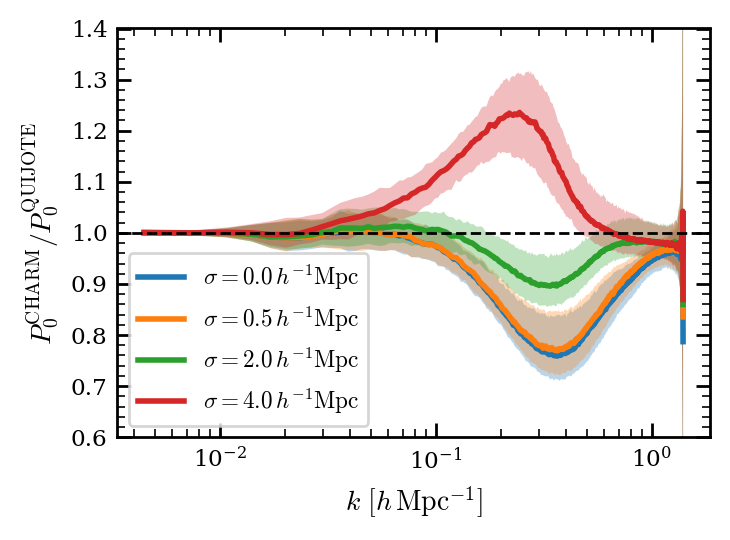

In [80]:
fig, ax = plt.subplots(1, 1, figsize=(3.75, 2.8))

for noise in use_noise:
    if noise == 'no':
        label = 0
    else:
        label = noise
    label = r'$\sigma = %.1f \, h^{-1} \mathrm{Mpc}$' % label
    p16, med, p84 = np.percentile(quijote_ratios[noise], [16, 50, 84], axis=0)
    ax.plot(k_charm, med[:, 0], label=label, lw=2)
    ax.fill_between(k_charm, p16[:, 0], p84[:, 0], alpha=0.3)

ax.set_xscale('log')
ax.set_xlabel(r'$k \ [h \, \mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_0^{\rm CHARM}/P_0^{\rm QUIJOTE}$')
ax.set_ylim(0.6, 1.4)
ax.axhline(1, ls='--', color='k', lw=1)
ax.legend(fancybox=True, frameon=True, loc='lower left')
fig.tight_layout()
fig.savefig(os.path.join(imdir, 'pk_sigma_noise.pdf'),
            dpi=400, bbox_inches='tight')